# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [2]:
import pandas as pd
import sklearn

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [3]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [5]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

The target is categorical, so this is a classification task

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
print(X.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

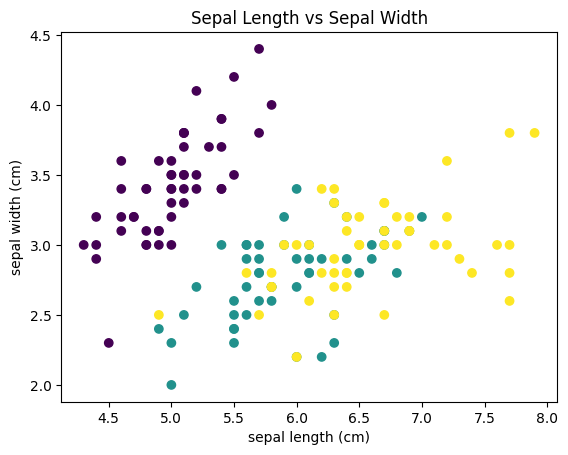

In [8]:
import matplotlib.pyplot as plt

plt.scatter(
    X['sepal length (cm)'],
    X['sepal width (cm)'],
    c=y,
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [9]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]

### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [10]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [11]:
from sklearn.linear_model import LogisticRegression

model_sepal = LogisticRegression()
model_petal = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [12]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sepal, y, test_size=0.2, random_state=42, stratify=y)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_petal, y, test_size=0.2, random_state=42, stratify=y)

### Step 9.a Train both models

In [13]:
model_sepal.fit(X_train_s, y_train_s)
model_petal.fit(X_train_p, y_train_p)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [14]:
print("Sepal accuracy:", model_sepal.score(X_test_s, y_test_s))
print("Petal accuracy:", model_petal.score(X_test_p, y_test_p))

Sepal accuracy: 0.7333333333333333
Petal accuracy: 0.9666666666666667


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

Petal features better distinguish iris flowers because their classes are more clearly separable.

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

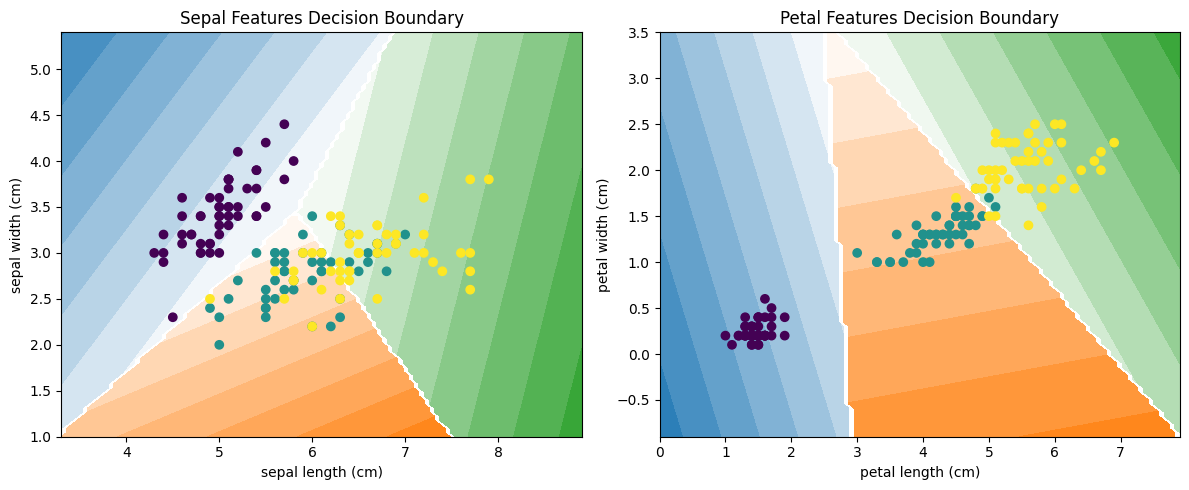

In [15]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sepal
DecisionBoundaryDisplay.from_estimator(model_sepal, X_sepal, ax=axes[0])
axes[0].scatter(
    X_sepal.iloc[:, 0],
    X_sepal.iloc[:, 1],
    c=y,
    cmap='viridis'
)
axes[0].set_title("Sepal Features Decision Boundary")
axes[0].set_xlabel("sepal length (cm)")
axes[0].set_ylabel("sepal width (cm)")

# Petal
DecisionBoundaryDisplay.from_estimator(model_petal, X_petal, ax=axes[1])
axes[1].scatter(
    X_petal.iloc[:, 0],
    X_petal.iloc[:, 1],
    c=y,
    cmap='viridis'
)
axes[1].set_title("Petal Features Decision Boundary")
axes[1].set_xlabel("petal length (cm)")
axes[1].set_ylabel("petal width (cm)")

plt.tight_layout()
plt.show()